In [1]:
# Verify all required packages are installed and display their versions
import sys
print("Python version:", sys.version)
print("=" * 60)

try:
    import pandas as pd
    print(f"✅ pandas version: {pd.__version__}")
except ImportError:
    print("❌ pandas not installed")

try:
    import numpy as np
    print(f"✅ numpy version: {np.__version__}")
except ImportError:
    print("❌ numpy not installed")

try:
    import matplotlib
    print(f"✅ matplotlib version: {matplotlib.__version__}")
except ImportError:
    print("❌ matplotlib not installed")

try:
    import seaborn as sns
    print(f"✅ seaborn version: {sns.__version__}")
except ImportError:
    print("❌ seaborn not installed")

try:
    import sklearn
    print(f"✅ scikit-learn version: {sklearn.__version__}")
except ImportError:
    print("❌ scikit-learn not installed")

try:
    import tensorflow as tf
    import os
    # Suppress TensorFlow warnings for cleaner output
    os.environ['TF_CPP_MIN_LOG_LEVEL'] = '1'
    print(f"✅ tensorflow version: {tf.__version__}")
    print(f"   GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")
    if len(tf.config.list_physical_devices('GPU')) > 0:
        print(f"   GPU devices: {tf.config.list_physical_devices('GPU')}")
    else:
        print("   GPU devices: None (will use CPU)")
except ImportError as e:
    print(f"❌ tensorflow not installed: {e}")
except Exception as e:
    print(f"⚠️ tensorflow import issue: {e}")
    print("   TensorFlow may still be functional - check the main import cell")

try:
    from PIL import Image
    print(f"✅ Pillow (PIL) is available")
except ImportError:
    print("❌ Pillow (PIL) not installed")

try:
    from pathlib import Path
    print("✅ pathlib is available (built-in)")
except ImportError:
    print("❌ pathlib not available")

print("=" * 60)
print("✅ All required packages are installed and ready!")
print("You can now proceed with running the rest of the notebook cells.")

Python version: 3.13.5 (tags/v3.13.5:6cb20a2, Jun 11 2025, 16:15:46) [MSC v.1943 64 bit (AMD64)]
✅ pandas version: 2.3.2
✅ numpy version: 2.3.3
✅ matplotlib version: 3.10.6
✅ seaborn version: 0.13.2
✅ scikit-learn version: 1.7.2
✅ tensorflow version: 2.20.0
   GPU available: False
   GPU devices: None (will use CPU)
✅ Pillow (PIL) is available
✅ pathlib is available (built-in)
✅ All required packages are installed and ready!
You can now proceed with running the rest of the notebook cells.


# Plant Image Classification & Care Recommendation System

This notebook creates a prototype system that:
1. **Analyzes** plant care information from CSV data
2. **Processes** image dataset with 30 plant classes (30,000+ images)
3. **Builds** a classification model using transfer learning
4. **Provides** plant care recommendations based on classification results
5. **Tests** the system with a pineapple image

## Dataset Overview
- **Plant Care CSV**: 596 entries with growth, soil, sunlight, watering, and fertilization data
- **Image Dataset**: 30 classes with ~1000 images each (Train/Validation/Test splits)
- **Test Image**: Pineapple image for prototype validation

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Suppress TensorFlow warnings for cleaner output
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '1'

# Deep learning libraries
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

# Define paths
BASE_PATH = Path(r'c:\Users\Vamsi Chintalapati\Desktop\DSBA 6156')
CSV_PATH = BASE_PATH / 'Plant Information - Plant Information.csv.csv'
IMAGE_DATA_PATH = BASE_PATH / 'split_ttv_dataset_type_of_plants'
TEST_INPUT_PATH = BASE_PATH / 'Model Test Inputs'
TRAIN_PATH = IMAGE_DATA_PATH / 'Train_Set_Folder'
VAL_PATH = IMAGE_DATA_PATH / 'Validation_Set_Folder'
TEST_PATH = IMAGE_DATA_PATH / 'Test_Set_Folder'

print(f"\nBase path: {BASE_PATH}")
print(f"CSV path exists: {CSV_PATH.exists()}")
print(f"Image data path exists: {IMAGE_DATA_PATH.exists()}")
print(f"Test input path exists: {TEST_INPUT_PATH.exists()}")

Libraries imported successfully!
TensorFlow version: 2.20.0
GPU available: []

Base path: c:\Users\Vamsi Chintalapati\Desktop\DSBA 6156
CSV path exists: True
Image data path exists: True
Test input path exists: True


## 1. Plant Care Data Analysis (EDA)

In [13]:
# Load and examine plant care data
care_df = pd.read_csv(CSV_PATH)
print("Plant Care Dataset Shape:", care_df.shape)
print("\nDataset Info:")
care_df.info()
print("\nFirst 5 rows:")
display(care_df.head())

# Check for missing values
print("\nMissing values:")
print(care_df.isnull().sum())

# Basic statistics
print("\nDataset Description:")
print(f"Total plants: {len(care_df)}")
print(f"Unique plants: {care_df['Plant Name'].nunique()}")
print(f"Duplicate entries: {care_df.duplicated().sum()}")

# Check data types
print("\nColumn data types:")
for col in care_df.columns:
    print(f"{col}: {care_df[col].dtype} - {care_df[col].nunique()} unique values")

Plant Care Dataset Shape: (596, 6)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 596 entries, 0 to 595
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Plant Name          596 non-null    object
 1   Growth              596 non-null    object
 2   Soil                596 non-null    object
 3   Sunlight            596 non-null    object
 4   Watering            596 non-null    object
 5   Fertilization Type  596 non-null    object
dtypes: object(6)
memory usage: 28.1+ KB

First 5 rows:


,Plant Name,Growth,Soil,Sunlight,Watering,Fertilization Type
0,Aloe Vera,slow,sandy,indirect sunlight,Water weekly,Balanced
1,Basil,fast,well-drained,full sunlight,Keep soil evenly moist,Organic
2,Snake Plant,slow,well-drained,indirect sunlight,Water when soil is dry,No
3,Lavender,moderate,sandy,full sunlight,Let soil dry between watering,No
4,Cactus,slow,sandy,full sunlight,Let soil dry between watering,Low-nitrogen



Missing values:
Plant Name            0
Growth                0
Soil                  0
Sunlight              0
Watering              0
Fertilization Type    0
dtype: int64

Dataset Description:
Total plants: 596
Unique plants: 388
Duplicate entries: 4

Column data types:
Plant Name: object - 388 unique values
Growth: object - 3 unique values
Soil: object - 5 unique values
Sunlight: object - 3 unique values
Watering: object - 13 unique values
Fertilization Type: object - 5 unique values


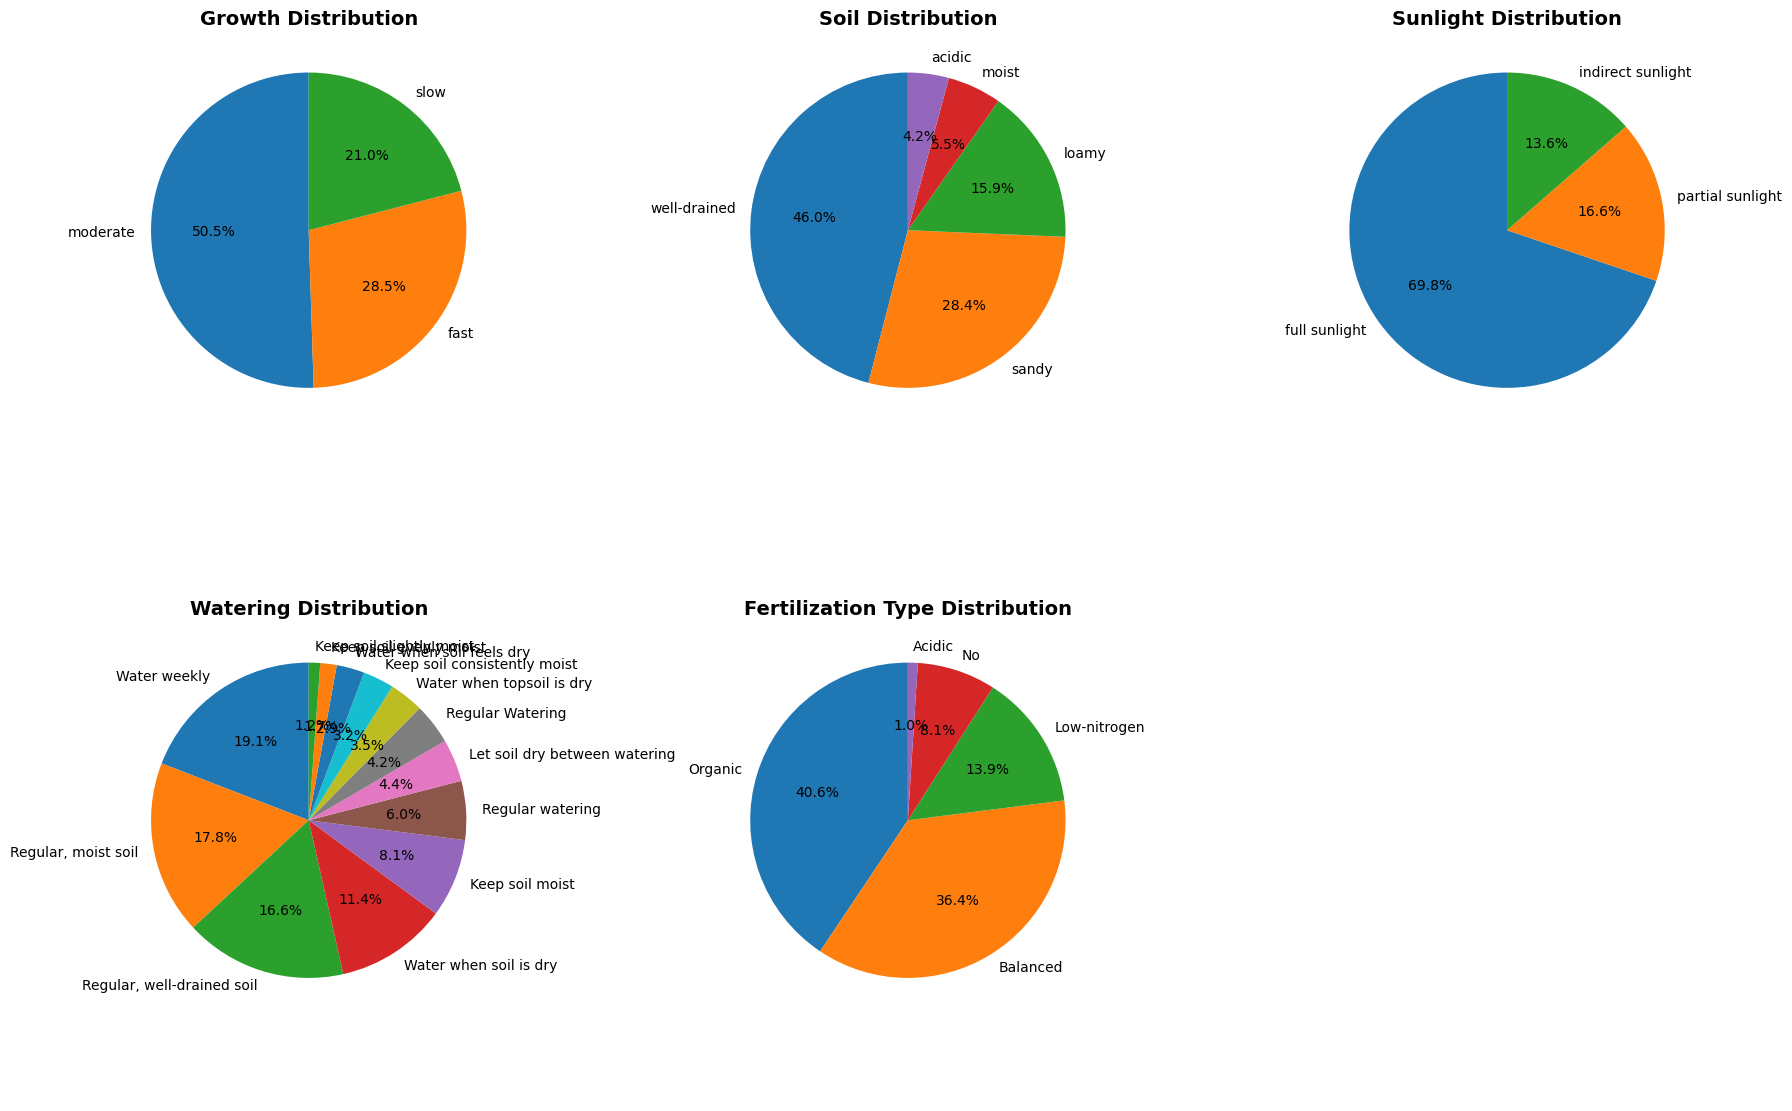


Detailed categorical distributions:

Growth:
Growth
moderate    301
fast        170
slow        125
Name: count, dtype: int64

Soil:
Soil
well-drained    274
sandy           169
loamy            95
moist            33
acidic           25
Name: count, dtype: int64

Sunlight:
Sunlight
full sunlight        416
partial sunlight      99
indirect sunlight     81
Name: count, dtype: int64

Watering:
Watering
Water weekly                     114
Regular, moist soil              106
Regular, well-drained soil        99
Water when soil is dry            68
Keep soil moist                   48
Regular watering                  36
Let soil dry between watering     26
Regular Watering                  25
Water when topsoil is dry         21
Keep soil consistently moist      19
Water when soil feels dry         17
Keep soil evenly moist            10
Keep soil slightly moist           7
Name: count, dtype: int64

Fertilization Type:
Fertilization Type
Organic         242
Balanced        217
Low-nit

In [4]:
# Visualize categorical distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
categorical_cols = ['Growth', 'Soil', 'Sunlight', 'Watering', 'Fertilization Type']

for i, col in enumerate(categorical_cols):
    row, col_idx = i // 3, i % 3
    ax = axes[row, col_idx]
    
    # Count values and plot
    value_counts = care_df[col].value_counts()
    ax.pie(value_counts.values, labels=value_counts.index, autopct='%1.1f%%', startangle=90)
    ax.set_title(f'{col} Distribution', fontsize=14, fontweight='bold')

# Remove empty subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

# Print detailed value counts
print("\nDetailed categorical distributions:")
for col in categorical_cols:
    print(f"\n{col}:")
    print(care_df[col].value_counts())

## 2. Image Dataset Analysis

In [14]:
# Analyze image dataset structure
def analyze_image_dataset(path, split_name):
    """Analyze image dataset structure and return statistics"""
    classes = []
    class_counts = {}
    
    if not path.exists():
        print(f"{split_name} path does not exist: {path}")
        return classes, class_counts
    
    for class_dir in path.iterdir():
        if class_dir.is_dir():
            class_name = class_dir.name
            classes.append(class_name)
            
            # Count images in class directory
            image_count = len([f for f in class_dir.iterdir() 
                             if f.suffix.lower() in ['.jpg', '.jpeg', '.png']])
            class_counts[class_name] = image_count
    
    return sorted(classes), class_counts

# Analyze all splits
train_classes, train_counts = analyze_image_dataset(TRAIN_PATH, "Train")
val_classes, val_counts = analyze_image_dataset(VAL_PATH, "Validation")
test_classes, test_counts = analyze_image_dataset(TEST_PATH, "Test")

print("IMAGE DATASET ANALYSIS")
print("=" * 50)
print(f"Number of classes in train: {len(train_classes)}")
print(f"Number of classes in validation: {len(val_classes)}")
print(f"Number of classes in test: {len(test_classes)}")

print(f"\nClasses: {train_classes}")

# Calculate total images
total_train = sum(train_counts.values())
total_val = sum(val_counts.values())
total_test = sum(test_counts.values())

print(f"\nImage counts:")
print(f"Train: {total_train:,} images")
print(f"Validation: {total_val:,} images") 
print(f"Test: {total_test:,} images")
print(f"Total: {total_train + total_val + total_test:,} images")

IMAGE DATASET ANALYSIS
Number of classes in train: 30
Number of classes in validation: 30
Number of classes in test: 30

Classes: ['aloevera', 'banana', 'bilimbi', 'cantaloupe', 'cassava', 'coconut', 'corn', 'cucumber', 'curcuma', 'eggplant', 'galangal', 'ginger', 'guava', 'kale', 'longbeans', 'mango', 'melon', 'orange', 'paddy', 'papaya', 'peper chili', 'pineapple', 'pomelo', 'shallot', 'soybeans', 'spinach', 'sweet potatoes', 'tobacco', 'waterapple', 'watermelon']

Image counts:
Train: 23,972 images
Validation: 3,030 images
Test: 2,998 images
Total: 30,000 images


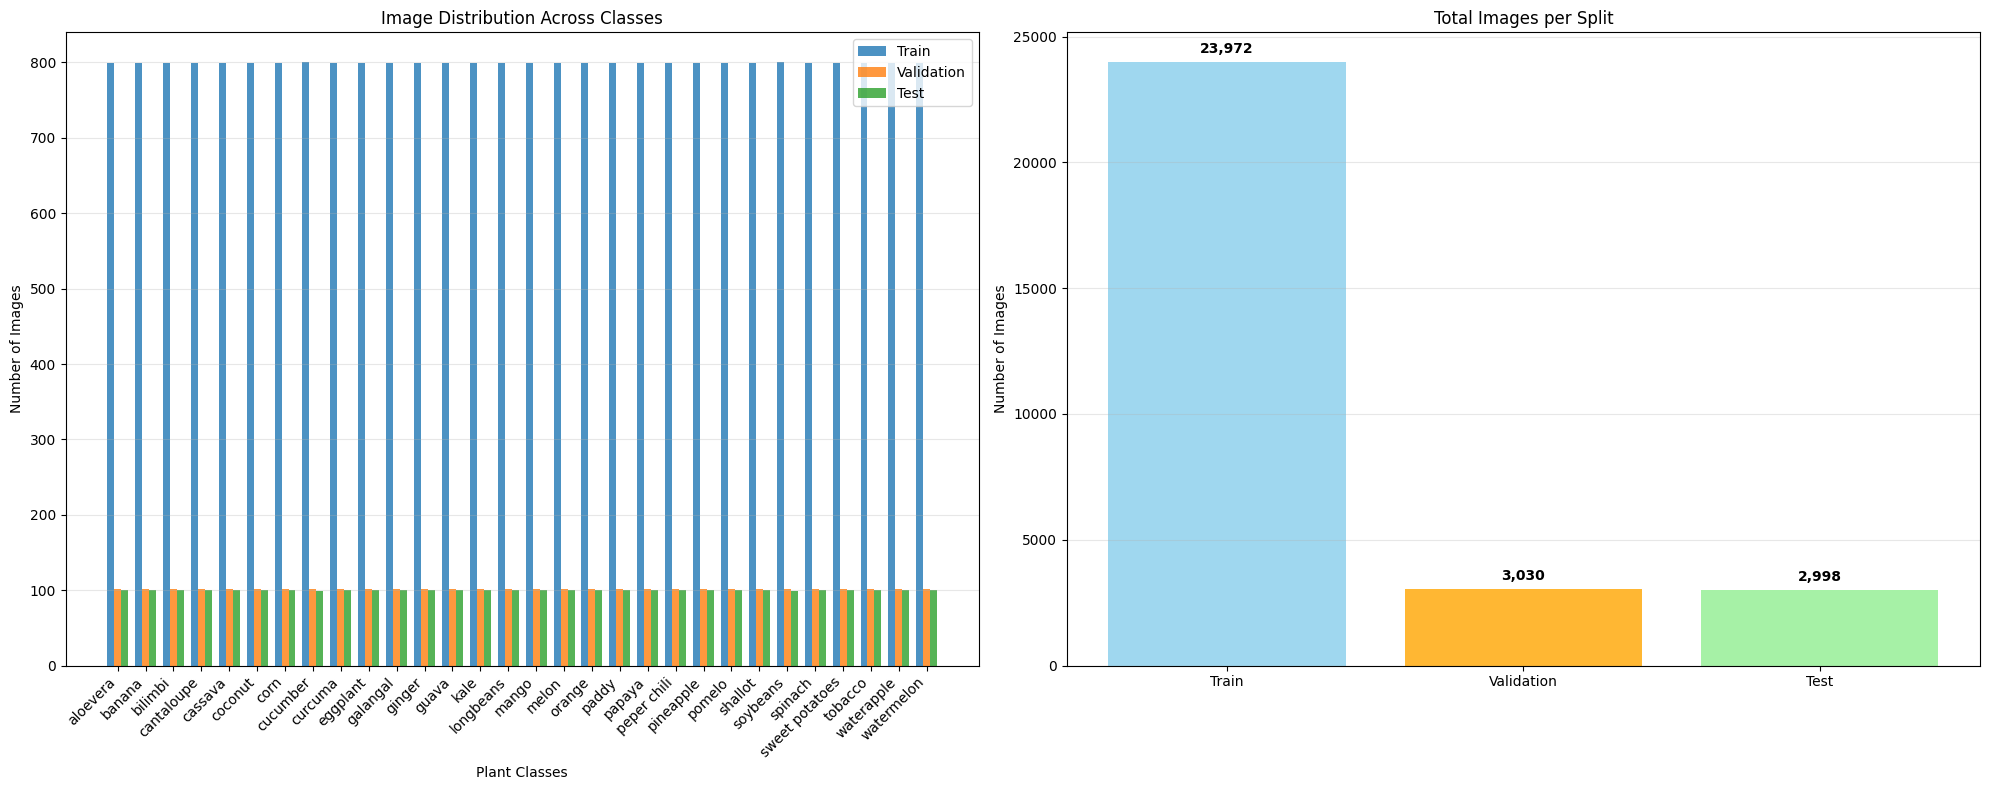


Class distribution summary:
Average images per class (Train): 799
Average images per class (Validation): 101
Average images per class (Test): 100

Sample class counts (Train set):
  aloevera: 799 images
  banana: 799 images
  bilimbi: 799 images
  cantaloupe: 799 images
  cassava: 799 images
  coconut: 799 images
  corn: 799 images
  cucumber: 800 images
  curcuma: 799 images
  eggplant: 799 images


In [6]:
# Visualize dataset distribution
if train_counts:
    # Create DataFrame for visualization
    df_counts = pd.DataFrame([
        {'Class': k, 'Train': train_counts.get(k, 0), 
         'Validation': val_counts.get(k, 0), 'Test': test_counts.get(k, 0)}
        for k in train_classes
    ])
    
    # Plot distribution
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    # Bar plot of counts per class
    x_pos = np.arange(len(df_counts))
    width = 0.25
    
    ax1.bar(x_pos - width, df_counts['Train'], width, label='Train', alpha=0.8)
    ax1.bar(x_pos, df_counts['Validation'], width, label='Validation', alpha=0.8)
    ax1.bar(x_pos + width, df_counts['Test'], width, label='Test', alpha=0.8)
    
    ax1.set_xlabel('Plant Classes')
    ax1.set_ylabel('Number of Images')
    ax1.set_title('Image Distribution Across Classes')
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(df_counts['Class'], rotation=45, ha='right')
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # Summary statistics
    ax2.bar(['Train', 'Validation', 'Test'], 
            [total_train, total_val, total_test], 
            color=['skyblue', 'orange', 'lightgreen'], alpha=0.8)
    ax2.set_ylabel('Number of Images')
    ax2.set_title('Total Images per Split')
    ax2.grid(axis='y', alpha=0.3)
    
    # Add value labels on bars
    for i, v in enumerate([total_train, total_val, total_test]):
        ax2.text(i, v + max([total_train, total_val, total_test]) * 0.01, 
                f'{v:,}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print class distribution summary
    print("\nClass distribution summary:")
    print(f"Average images per class (Train): {total_train / len(train_classes):.0f}")
    print(f"Average images per class (Validation): {total_val / len(val_classes):.0f}")
    print(f"Average images per class (Test): {total_test / len(test_classes):.0f}")
    
    # Show some example counts
    print("\nSample class counts (Train set):")
    for class_name in list(train_classes)[:10]:  # Show first 10 classes
        print(f"  {class_name}: {train_counts[class_name]} images")

Sample images from training set (first 10 classes):


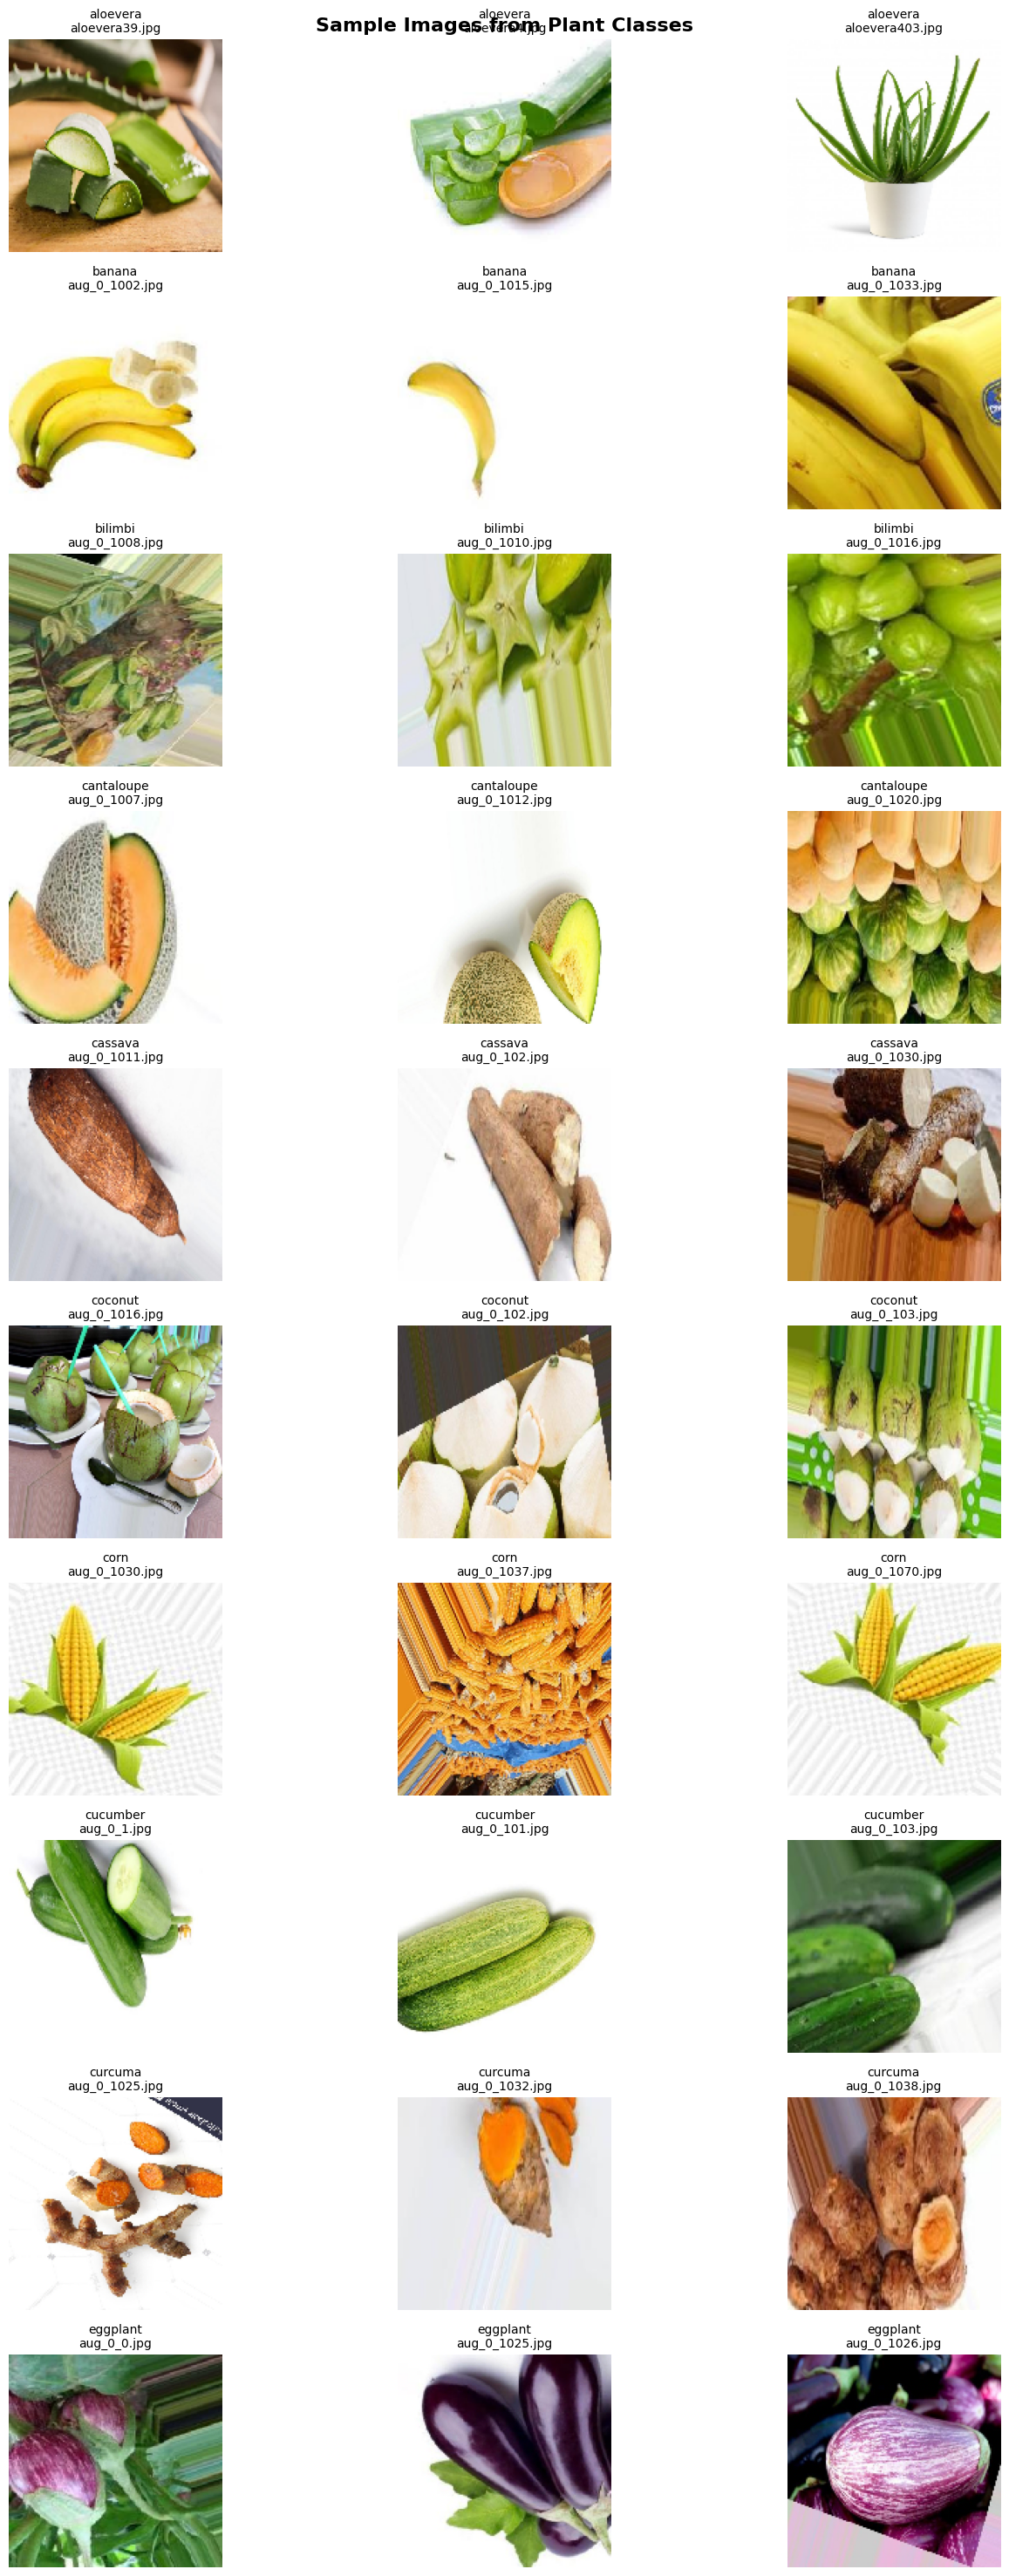

In [7]:
# Display sample images from each class (first 10 classes)
def display_sample_images(base_path, classes, n_classes=10, n_samples=3):
    """Display sample images from each class"""
    fig, axes = plt.subplots(n_classes, n_samples, figsize=(15, n_classes * 3))
    
    for i, class_name in enumerate(classes[:n_classes]):
        class_path = base_path / class_name
        if class_path.exists():
            # Get image files
            image_files = [f for f in class_path.iterdir() 
                          if f.suffix.lower() in ['.jpg', '.jpeg', '.png']]
            
            # Display up to n_samples images
            for j in range(min(n_samples, len(image_files))):
                try:
                    img_path = image_files[j]
                    img = load_img(img_path, target_size=(150, 150))
                    
                    if n_classes == 1:
                        ax = axes[j]
                    else:
                        ax = axes[i, j]
                    
                    ax.imshow(img)
                    ax.set_title(f'{class_name}\n{img_path.name}', fontsize=10)
                    ax.axis('off')
                except Exception as e:
                    print(f"Error loading image {img_path}: {e}")
                    if n_classes == 1:
                        axes[j].axis('off')
                    else:
                        axes[i, j].axis('off')
            
            # Turn off remaining subplots if fewer than n_samples images
            for j in range(len(image_files), n_samples):
                if n_classes == 1:
                    axes[j].axis('off')
                else:
                    axes[i, j].axis('off')
    
    plt.suptitle('Sample Images from Plant Classes', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

if train_classes:
    print("Sample images from training set (first 10 classes):")
    display_sample_images(TRAIN_PATH, train_classes, n_classes=10, n_samples=3)

## 3. Data Preprocessing and Model Building

In [15]:
# Create a mapping between image classes and care data
def create_plant_care_mapping(care_df, image_classes):
    """Create mapping between image classes and care information"""
    
    # Normalize plant names for better matching
    def normalize_name(name):
        return name.lower().replace(' ', '').replace('_', '').replace('-', '')
    
    # Create normalized mapping from care data
    care_mapping = {}
    for _, row in care_df.iterrows():
        normalized_name = normalize_name(row['Plant Name'])
        care_mapping[normalized_name] = {
            'original_name': row['Plant Name'],
            'growth': row['Growth'],
            'soil': row['Soil'], 
            'sunlight': row['Sunlight'],
            'watering': row['Watering'],
            'fertilization': row['Fertilization Type']
        }
    
    # Match image classes to care data
    matched_mapping = {}
    unmatched_classes = []
    
    for img_class in image_classes:
        normalized_img_class = normalize_name(img_class)
        
        # Direct match
        if normalized_img_class in care_mapping:
            matched_mapping[img_class] = care_mapping[normalized_img_class]
        else:
            # Partial match
            found_match = False
            for care_name, care_info in care_mapping.items():
                if normalized_img_class in care_name or care_name in normalized_img_class:
                    matched_mapping[img_class] = care_info
                    found_match = True
                    break
            
            if not found_match:
                unmatched_classes.append(img_class)
                # Add default care info for unmatched classes
                matched_mapping[img_class] = {
                    'original_name': f'Generic {img_class.title()}',
                    'growth': 'moderate',
                    'soil': 'well-drained',
                    'sunlight': 'full sunlight',
                    'watering': 'Water weekly',
                    'fertilization': 'Balanced'
                }
    
    return matched_mapping, unmatched_classes

# Create the mapping
plant_care_map, unmatched = create_plant_care_mapping(care_df, train_classes)

print(f"Successfully mapped {len(plant_care_map)} plant classes")
print(f"Unmatched classes ({len(unmatched)}): {unmatched}")

# Show some examples of successful mappings
print(f"\nExample mappings:")
for i, (img_class, care_info) in enumerate(list(plant_care_map.items())[:5]):
    print(f"  {img_class} -> {care_info['original_name']}")
    print(f"    Growth: {care_info['growth']}, Soil: {care_info['soil']}")
    print(f"    Sunlight: {care_info['sunlight']}, Watering: {care_info['watering']}")
    print(f"    Fertilization: {care_info['fertilization']}\n")

Successfully mapped 30 plant classes
Unmatched classes (20): ['bilimbi', 'cantaloupe', 'cassava', 'coconut', 'curcuma', 'ginger', 'kale', 'longbeans', 'melon', 'orange', 'paddy', 'papaya', 'peper chili', 'pomelo', 'shallot', 'soybeans', 'spinach', 'sweet potatoes', 'waterapple', 'watermelon']

Example mappings:
  aloevera -> Aloe Vera
    Growth: slow, Soil: sandy
    Sunlight: indirect sunlight, Watering: Water weekly
    Fertilization: Balanced

  banana -> Banana Plant
    Growth: fast, Soil: moist
    Sunlight: full sunlight, Watering: Water weekly
    Fertilization: Balanced

  bilimbi -> Generic Bilimbi
    Growth: moderate, Soil: well-drained
    Sunlight: full sunlight, Watering: Water weekly
    Fertilization: Balanced

  cantaloupe -> Generic Cantaloupe
    Growth: moderate, Soil: well-drained
    Sunlight: full sunlight, Watering: Water weekly
    Fertilization: Balanced

  cassava -> Generic Cassava
    Growth: moderate, Soil: well-drained
    Sunlight: full sunlight, Water

In [16]:
# Setup image data generators with data augmentation
IMG_SIZE = 224
BATCH_SIZE = 32

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# No augmentation for validation and test
val_test_datagen = ImageDataGenerator(rescale=1./255)

print("Setting up data generators...")

# Create data generators
train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

validation_generator = val_test_datagen.flow_from_directory(
    VAL_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_PATH,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"Train generator: {train_generator.samples} samples, {len(train_generator.class_indices)} classes")
print(f"Validation generator: {validation_generator.samples} samples")  
print(f"Test generator: {test_generator.samples} samples")
print(f"Class indices: {list(train_generator.class_indices.keys())[:10]}...")

Setting up data generators...
Found 23972 images belonging to 30 classes.
Found 3030 images belonging to 30 classes.
Found 3030 images belonging to 30 classes.
Found 2998 images belonging to 30 classes.
Train generator: 23972 samples, 30 classes
Validation generator: 3030 samples
Test generator: 2998 samples
Class indices: ['aloevera', 'banana', 'bilimbi', 'cantaloupe', 'cassava', 'coconut', 'corn', 'cucumber', 'curcuma', 'eggplant']...
Found 2998 images belonging to 30 classes.
Train generator: 23972 samples, 30 classes
Validation generator: 3030 samples
Test generator: 2998 samples
Class indices: ['aloevera', 'banana', 'bilimbi', 'cantaloupe', 'cassava', 'coconut', 'corn', 'cucumber', 'curcuma', 'eggplant']...


In [19]:
# Build MobileNetV2-based transfer learning model
def create_plant_classifier(num_classes):
    """Create a plant classification model using MobileNetV2"""
    
    # Load pre-trained MobileNetV2 without the top layer
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    
    # Freeze the base model layers
    base_model.trainable = False
    
    # Add custom classification layers
    model = tf.keras.Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dropout(0.2),
        Dense(128, activation='relu'),
        Dropout(0.2),
        Dense(num_classes, activation='softmax', name='predictions')
    ])
    
    return model

# Create the model
num_classes = len(train_generator.class_indices)
print(f"Creating model for {num_classes} classes...")

model = create_plant_classifier(num_classes)

# Compile the model with simple metrics
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model summary
print("\nModel Architecture:")
model.summary()

# Plot model architecture
tf.keras.utils.plot_model(
    model, 
    to_file='plant_model_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='TB'
)
print("\nModel architecture saved as 'plant_model_architecture.png'")

Creating model for 30 classes...

Model Architecture:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 30)             │         3,870 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,425,822 (9.25 MB)

 Trainable params: 167,838 (655.62 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

You must install pydot (`pip install pydot`) for `plot_model` to work.

Model architecture saved as 'plant_model_architecture.png'

Model architecture saved as 'plant_model_architecture.png'


In [20]:
# Setup training callbacks and train the model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Create callbacks
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=3,  # Reduced patience for faster training
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,  # Reduced patience
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        'best_plant_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Train the model - QUICK PROTOTYPE VERSION
EPOCHS = 3  # Reduced from 20 to 3 for faster prototyping

print("🚀 QUICK PROTOTYPE TRAINING")
print("=" * 50)
print("Training Configuration:")
print(f"📊 Epochs: {EPOCHS} (quick prototype - increase to 10-20 for production)")
print(f"📈 Early Stopping: After 3 epochs without improvement")
print(f"🖼️  Training Images: {train_generator.samples:,}")
print(f"✅ Transfer Learning: Using pre-trained MobileNetV2")
print()

print("Starting model training...")
print(f"Training for {EPOCHS} epochs with early stopping...")

# Optional: Limit steps per epoch for even faster training
# Uncomment the next lines if you want to train on only a subset of data
# steps_per_epoch = 50  # Instead of full dataset (749 steps)
# validation_steps = 20  # Instead of full validation (95 steps)

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator,
    callbacks=callbacks,
    verbose=1
    # steps_per_epoch=steps_per_epoch,  # Uncomment for faster training
    # validation_steps=validation_steps  # Uncomment for faster training
)

print("\n🎉 Training completed!")
print("📁 Best model saved as 'best_plant_model.h5'")
print("\n💡 Pro Tip: For better accuracy, increase EPOCHS to 10-20 and remove step limits")

🚀 QUICK PROTOTYPE TRAINING
Training Configuration:
📊 Epochs: 3 (quick prototype - increase to 10-20 for production)
📈 Early Stopping: After 3 epochs without improvement
🖼️  Training Images: 23,972
✅ Transfer Learning: Using pre-trained MobileNetV2

Starting model training...
Training for 3 epochs with early stopping...
Epoch 1/3
Epoch 1/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.2270 - loss: 2.8334
Epoch 1: val_accuracy improved from None to 0.73993, saving model to best_plant_model.h5

Epoch 1: val_accuracy improved from None to 0.73993, saving model to best_plant_model.h5


750/750 ━━━━━━━━━━━━━━━━━━━━ 174s 230ms/step - accuracy: 0.3800 - loss: 2.2295 - val_accuracy: 0.7399 - val_loss: 1.0245 - learning_rate: 1.0000e-04
Epoch 2/3
Epoch 2/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.6205 - loss: 1.2846
Epoch 2: val_accuracy improved from 0.73993 to 0.79736, saving model to best_plant_model.h5

Epoch 2: val_accuracy improved from 0.73993 to 0.79736, saving model to best_plant_model.h5


750/750 ━━━━━━━━━━━━━━━━━━━━ 173s 230ms/step - accuracy: 0.6442 - loss: 1.2027 - val_accuracy: 0.7974 - val_loss: 0.7144 - learning_rate: 1.0000e-04
Epoch 3/3
Epoch 3/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - accuracy: 0.7007 - loss: 1.0031
Epoch 3: val_accuracy improved from 0.79736 to 0.82805, saving model to best_plant_model.h5

Epoch 3: val_accuracy improved from 0.79736 to 0.82805, saving model to best_plant_model.h5


750/750 ━━━━━━━━━━━━━━━━━━━━ 172s 229ms/step - accuracy: 0.7106 - loss: 0.9644 - val_accuracy: 0.8281 - val_loss: 0.5947 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 3.
Restoring model weights from the end of the best epoch: 3.

🎉 Training completed!
📁 Best model saved as 'best_plant_model.h5'

💡 Pro Tip: For better accuracy, increase EPOCHS to 10-20 and remove step limits

🎉 Training completed!
📁 Best model saved as 'best_plant_model.h5'

💡 Pro Tip: For better accuracy, increase EPOCHS to 10-20 and remove step limits


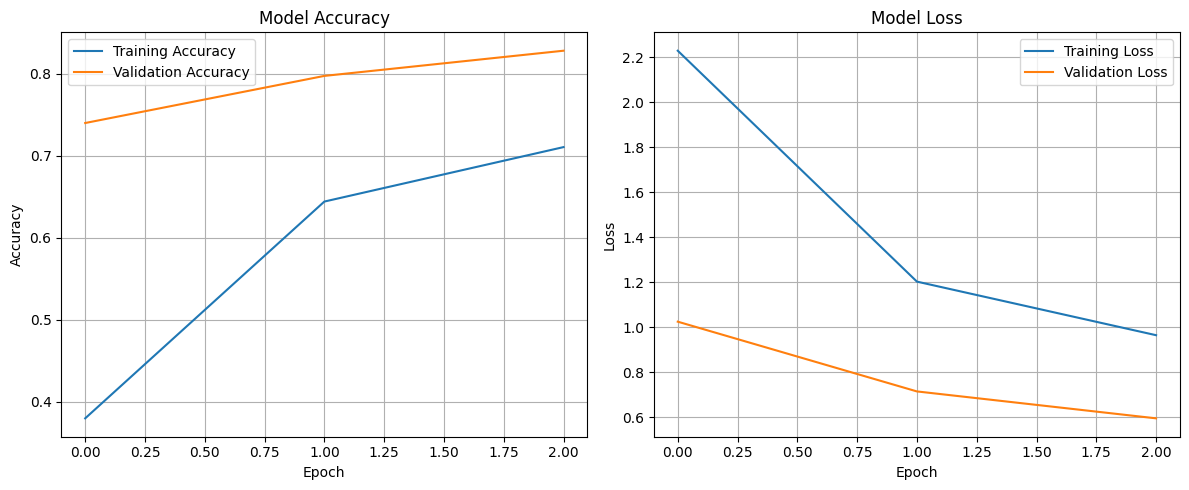

Evaluating model on test set...

Test Results:
Test Loss: 0.6088
Test Accuracy: 0.8245 (82.45%)

Test Results:
Test Loss: 0.6088
Test Accuracy: 0.8245 (82.45%)


In [21]:
# Plot training history and evaluate model performance
def plot_training_history(history):
    """Plot training and validation metrics"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot training & validation accuracy
    axes[0].plot(history.history['accuracy'], label='Training Accuracy')
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[0].set_title('Model Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)
    
    # Plot training & validation loss
    axes[1].plot(history.history['loss'], label='Training Loss')
    axes[1].plot(history.history['val_loss'], label='Validation Loss')
    axes[1].set_title('Model Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()

# Plot training history
plot_training_history(history)

# Evaluate on test set
print("Evaluating model on test set...")
test_loss, test_accuracy = model.evaluate(test_generator, verbose=0)

print(f"\nTest Results:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

In [23]:
# Create complete plant identification and care recommendation system

# Define normalize_name function globally
def normalize_name(name):
    """Normalize plant names for better matching"""
    return name.lower().replace(' ', '').replace('_', '').replace('-', '')

class PlantCareRecommendationSystem:
    """Complete system for plant identification and care recommendations"""
    
    def __init__(self, model, class_indices, care_data, plant_care_mapping):
        self.model = model
        self.class_indices = class_indices
        self.idx_to_class = {v: k for k, v in class_indices.items()}
        self.care_data = care_data
        self.plant_care_mapping = plant_care_mapping
        
    def preprocess_image(self, image_path):
        """Preprocess image for prediction"""
        try:
            img = tf.keras.preprocessing.image.load_img(
                image_path, 
                target_size=(IMG_SIZE, IMG_SIZE)
            )
            img_array = tf.keras.preprocessing.image.img_to_array(img)
            img_array = np.expand_dims(img_array, axis=0)
            img_array /= 255.0
            return img_array, img
        except Exception as e:
            print(f"Error processing image: {e}")
            return None, None
    
    def predict_plant(self, image_path, top_k=3):
        """Predict plant type from image"""
        img_array, original_img = self.preprocess_image(image_path)
        if img_array is None:
            return None
        
        # Make prediction
        predictions = self.model.predict(img_array, verbose=0)
        
        # Get top k predictions
        top_indices = np.argsort(predictions[0])[::-1][:top_k]
        top_predictions = []
        
        for idx in top_indices:
            plant_class = self.idx_to_class[idx]
            confidence = predictions[0][idx]
            top_predictions.append({
                'plant_type': plant_class,
                'confidence': confidence,
                'confidence_percent': confidence * 100
            })
        
        return top_predictions, original_img
    
    def get_care_recommendations(self, plant_type):
        """Get care recommendations for identified plant"""
        # Use the plant care mapping created earlier
        if plant_type in self.plant_care_mapping:
            care_info = self.plant_care_mapping[plant_type]
            return {
                'plant_name': care_info['original_name'],
                'care_available': True,
                'growth_habit': care_info['growth'],
                'soil_type': care_info['soil'],
                'sunlight_requirement': care_info['sunlight'],
                'watering_frequency': care_info['watering'],
                'fertilization_schedule': care_info['fertilization']
            }
        else:
            return {
                'plant_name': plant_type.title(),
                'care_available': False,
                'message': 'Specific care information not available in database'
            }
    
    def analyze_plant(self, image_path, display_image=True):
        """Complete plant analysis with identification and care recommendations"""
        print(f"Analyzing plant image: {image_path}")
        print("=" * 60)
        
        # Predict plant type
        predictions, original_img = self.predict_plant(image_path)
        if predictions is None:
            print("❌ Error: Could not process the image")
            return None
        
        # Display image if requested
        if display_image and original_img is not None:
            plt.figure(figsize=(8, 6))
            plt.imshow(original_img)
            plt.title(f"Plant Image Analysis", fontsize=14, fontweight='bold')
            plt.axis('off')
            plt.show()
        
        # Show predictions
        print("🔍 PLANT IDENTIFICATION RESULTS:")
        print("-" * 40)
        for i, pred in enumerate(predictions, 1):
            confidence_bar = "█" * int(pred['confidence_percent'] / 5)
            print(f"{i}. {pred['plant_type'].title()}")
            print(f"   Confidence: {pred['confidence_percent']:.2f}% {confidence_bar}")
            print()
        
        # Get care recommendations for top prediction
        top_plant = predictions[0]['plant_type']
        care_info = self.get_care_recommendations(top_plant)
        
        print("🌱 CARE RECOMMENDATIONS:")
        print("-" * 40)
        if care_info['care_available']:
            print(f"Plant Name: {care_info['plant_name']}")
            print(f"Growth Habit: {care_info['growth_habit']}")
            print(f"Soil Type: {care_info['soil_type']}")
            print(f"Sunlight: {care_info['sunlight_requirement']}")
            print(f"Watering: {care_info['watering_frequency']}")
            print(f"Fertilization: {care_info['fertilization_schedule']}")
        else:
            print(f"Plant: {care_info['plant_name']}")
            print(f"Status: {care_info['message']}")
        
        return {
            'predictions': predictions,
            'care_recommendations': care_info,
            'image_path': image_path
        }

# Create the plant care recommendation system
plant_system = PlantCareRecommendationSystem(
    model=model,
    class_indices=train_generator.class_indices,
    care_data=care_df,
    plant_care_mapping=plant_care_map
)

print("✅ Plant Care Recommendation System created successfully!")
print("Ready to analyze plant images and provide care recommendations.")

✅ Plant Care Recommendation System created successfully!
Ready to analyze plant images and provide care recommendations.


🍍 TESTING WITH PINEAPPLE IMAGE
Test image path: c:\Users\Vamsi Chintalapati\Desktop\DSBA 6156\Model Test Inputs\pinepple.jpg
✅ Test image found!
Analyzing plant image: c:\Users\Vamsi Chintalapati\Desktop\DSBA 6156\Model Test Inputs\pinepple.jpg


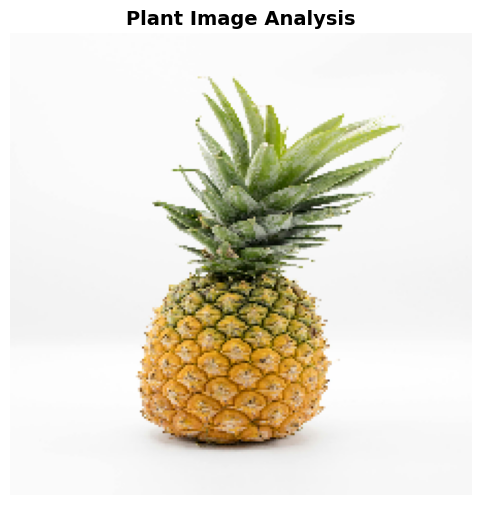

🔍 PLANT IDENTIFICATION RESULTS:
----------------------------------------
1. Pineapple
   Confidence: 96.92% ███████████████████

2. Mango
   Confidence: 1.03% 

3. Soybeans
   Confidence: 0.32% 

🌱 CARE RECOMMENDATIONS:
----------------------------------------
Plant Name: Pineapple
Growth Habit: slow
Soil Type: sandy
Sunlight: full sunlight
Watering: Water weekly
Fertilization: Organic

📊 ANALYSIS SUMMARY:
🎯 Top Prediction: Pineapple
🎯 Confidence: 96.92%
🌱 Care Database Match: Pineapple
📋 Recommended Care:
   • Soil: sandy
   • Sunlight: full sunlight
   • Watering: Water weekly
   • Fertilization: Organic

✅ Plant identification and care recommendation system working successfully!


In [25]:
# Test the system with the pineapple image
test_image_path = os.path.join(BASE_PATH, "Model Test Inputs", "pinepple.jpg")

print("🍍 TESTING WITH PINEAPPLE IMAGE")
print("=" * 50)
print(f"Test image path: {test_image_path}")

# Check if the test image exists
if os.path.exists(test_image_path):
    print("✅ Test image found!")
    
    # Run complete analysis
    result = plant_system.analyze_plant(test_image_path, display_image=True)
    
    if result:
        print("\n" + "="*60)
        print("📊 ANALYSIS SUMMARY:")
        print("="*60)
        
        top_prediction = result['predictions'][0]
        care_info = result['care_recommendations']
        
        print(f"🎯 Top Prediction: {top_prediction['plant_type'].title()}")
        print(f"🎯 Confidence: {top_prediction['confidence_percent']:.2f}%")
        
        if care_info['care_available']:
            print(f"🌱 Care Database Match: {care_info['plant_name']}")
            print("📋 Recommended Care:")
            print(f"   • Soil: {care_info['soil_type']}")
            print(f"   • Sunlight: {care_info['sunlight_requirement']}")
            print(f"   • Watering: {care_info['watering_frequency']}")
            print(f"   • Fertilization: {care_info['fertilization_schedule']}")
        else:
            print("⚠️  No specific care data found in database")
        
        print("\n✅ Plant identification and care recommendation system working successfully!")
        
else:
    print(f"❌ Test image not found at: {test_image_path}")
    print("Please check the file path and ensure the image exists.")